# Project: Aanwezigheden tijdens lessen

Doel: een **regressiemodel** trainen dat de **aanwezigheidsgraad** voorspelt voor een les in het B-gebouw van HOGENT op basis van WiFi-data.

> **Aanwezigheidsgraad** = UserCount / TotalStudents

Externe data: Belgische feestdagen/vakanties en historische weerdata (Open-Meteo, Gent).

In [2]:
import sys
assert sys.version_info >= (3, 12)

from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse('1.8.0')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import requests
import joblib
from datetime import date, timedelta

np.random.seed(42)
plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=12)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 1. Data laden

> **Stap 1 — database herstellen:** herstel `datasets/wifi/WifiDWH.bak` in SQL Server en pas `SERVER` hieronder aan.

In [7]:
# Pas SERVER aan naar jouw SQL Server instantie
# Voorbeelden: 'localhost', r'localhost\SQLEXPRESS', r'.\SQLEXPRESS'
SERVER = r'localhost\SQL2022'
DATABASE = 'WifiDWH'

conn_str = (
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)

In [8]:
query = '''
SELECT
    f.UserCount,
    f.TotalStudents,
    CAST(d.FullDate AS DATE)  AS FullDate,
    d.Month,
    d.Year,
    d.Weekday,
    tf.Hour                   AS FromHour,
    tf.Minutes                AS FromMinutes,
    tu.Hour                   AS UntilHour,
    tu.Minutes                AS UntilMinutes,
    c.ClassCode,
    c.ClassCredits,
    r.Code                    AS RoomCode,
    r.Category                AS RoomCategory,
    r.Capacity,
    sg.ProgramName,
    a.CanonicalActivity,
    CAST(a.IsCourse    AS INT) AS IsCourse,
    CAST(a.IsExam      AS INT) AS IsExam,
    CAST(a.IsPractical AS INT) AS IsPractical
FROM FactLecture  f
JOIN DimDate      d  ON f.DateKey      = d.DateKey
JOIN DimTime      tf ON f.FromTimeKey  = tf.TimeKey
JOIN DimTime      tu ON f.UntilTimeKey = tu.TimeKey
JOIN DimClass     c  ON f.ClassKey     = c.ClassKey
JOIN DimRoom      r  ON f.RoomKey      = r.RoomKey
JOIN DimSubgroup  sg ON f.SubgroupKey  = sg.SubgroupKey
JOIN DimActivity  a  ON f.ActivityKey  = a.ActivityKey
WHERE f.TotalStudents > 0
'''

conn = pyodbc.connect(conn_str)
df = pd.read_sql(query, conn)
conn.close()

df['FullDate'] = pd.to_datetime(df['FullDate'])
print(f'Geladen: {df.shape[0]:,} rijen, {df.shape[1]} kolommen')
df.head()

Geladen: 18,499 rijen, 20 kolommen


C:\Users\alexa\AppData\Local\Temp\ipykernel_38136\2746030860.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,UserCount,TotalStudents,FullDate,Month,Year,Weekday,FromHour,FromMinutes,UntilHour,UntilMinutes,ClassCode,ClassCredits,RoomCode,RoomCategory,Capacity,ProgramName,CanonicalActivity,IsCourse,IsExam,IsPractical
0,NaN,22,2026-03-28,3,2026,7,8,0,10,30,196085,4,01.02.110.037,laptoplokaal,32,GRAD-ACA1-GENT,Activerend hoorcollege,1,0,0
1,NaN,22,2026-04-04,4,2026,7,8,0,10,30,196085,4,01.02.110.037,laptoplokaal,32,GRAD-ACA1-GENT,Activerend hoorcollege,1,0,0
2,NaN,22,2026-04-25,4,2026,7,8,0,10,30,196085,4,01.02.110.037,laptoplokaal,32,GRAD-ACA1-GENT,Activerend hoorcollege,1,0,0
3,NaN,22,2026-05-02,5,2026,7,8,0,10,30,196085,4,01.02.110.037,laptoplokaal,32,GRAD-ACA1-GENT,Activerend hoorcollege,1,0,0
4,NaN,22,2026-05-09,5,2026,7,8,0,10,30,196085,4,01.02.110.037,laptoplokaal,32,GRAD-ACA1-GENT,Activerend hoorcollege,1,0,0


## 2. Doelveranderlijke

De aanwezigheidsgraad is het aandeel van de verwachte studenten dat effectief aanwezig was, gemeten via WiFi-verbindingen.

In [9]:
df['aanwezigheidsgraad'] = df['UserCount'] / df['TotalStudents']
df['aanwezigheidsgraad'].describe().round(3)

count    6977.000
mean        0.328
std         0.287
min         0.000
25%         0.026
50%         0.306
75%         0.533
max         1.000
Name: aanwezigheidsgraad, dtype: float64

## 3. Verkenning

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18499 entries, 0 to 18498
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype        
---  ------              --------------  -----        
 0   UserCount           6977 non-null   float64      
 1   TotalStudents       18499 non-null  int64        
 2   FullDate            18499 non-null  datetime64[s]
 3   Month               18499 non-null  int64        
 4   Year                18499 non-null  int64        
 5   Weekday             18499 non-null  int64        
 6   FromHour            18499 non-null  int64        
 7   FromMinutes         18499 non-null  int64        
 8   UntilHour           18499 non-null  int64        
 9   UntilMinutes        18499 non-null  int64        
 10  ClassCode           18499 non-null  str          
 11  ClassCredits        18499 non-null  int64        
 12  RoomCode            18499 non-null  str          
 13  RoomCategory        18499 non-null  str          
 14  Capacity         

C:\Users\alexa\AppData\Local\Temp\ipykernel_38136\3602644915.py:10: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[['UserCount', 'TotalStudents']].hist(bins=40, ax=axes[1], alpha=0.7)


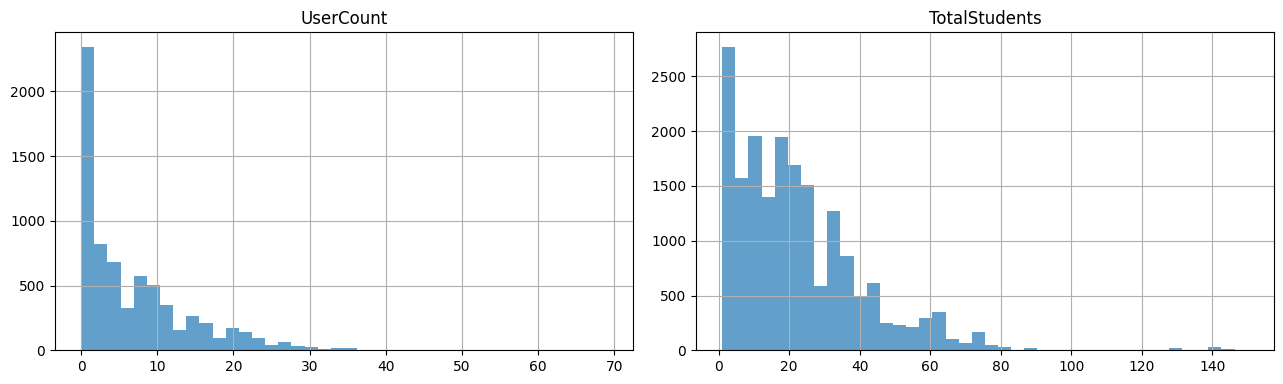

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['aanwezigheidsgraad'].hist(bins=60, ax=axes[0], edgecolor='white')
axes[0].set_title('Verdeling aanwezigheidsgraad')
axes[0].set_xlabel('Aanwezigheidsgraad')
axes[0].set_ylabel('Frequentie')
axes[0].axvline(df['aanwezigheidsgraad'].mean(), color='red', linestyle='--', label=f'Gemiddelde: {df["aanwezigheidsgraad"].mean():.2f}')
axes[0].legend()

df[['UserCount', 'TotalStudents']].hist(bins=40, ax=axes[1], alpha=0.7)
axes[1].set_title('UserCount vs TotalStudents')

plt.tight_layout()
plt.show()

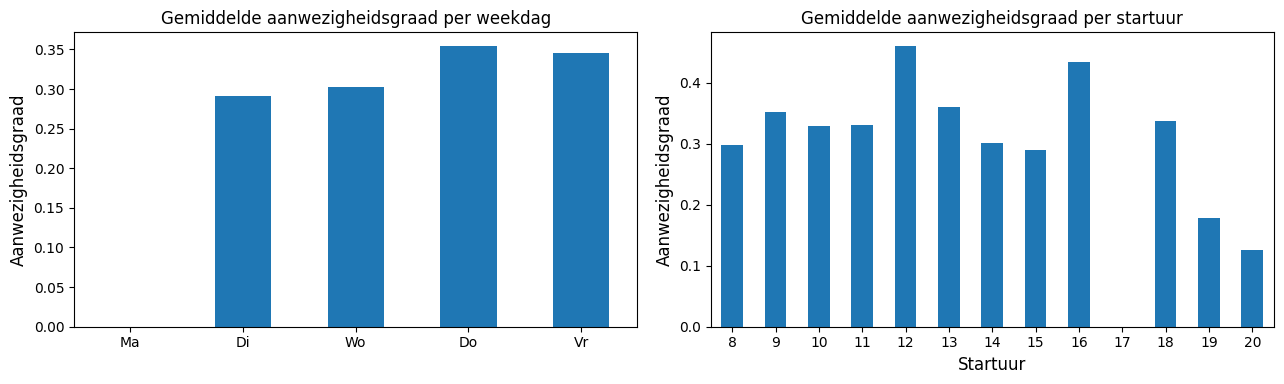

In [12]:
dag_namen = {1: 'Ma', 2: 'Di', 3: 'Wo', 4: 'Do', 5: 'Vr', 6: 'Za', 7: 'Zo'}
df['DagNaam'] = df['Weekday'].map(dag_namen)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

orde = ['Ma', 'Di', 'Wo', 'Do', 'Vr']
df.groupby('DagNaam')['aanwezigheidsgraad'].mean().reindex(orde).plot(kind='bar', ax=axes[0])
axes[0].set_title('Gemiddelde aanwezigheidsgraad per weekdag')
axes[0].set_ylabel('Aanwezigheidsgraad')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('FromHour')['aanwezigheidsgraad'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title('Gemiddelde aanwezigheidsgraad per startuur')
axes[1].set_ylabel('Aanwezigheidsgraad')
axes[1].set_xlabel('Startuur')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

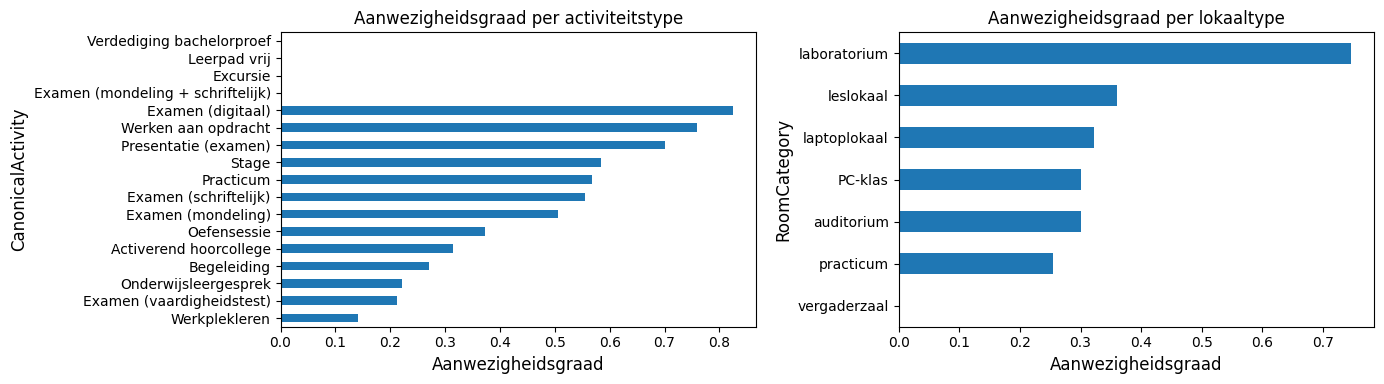

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('CanonicalActivity')['aanwezigheidsgraad'].mean().sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Aanwezigheidsgraad per activiteitstype')
axes[0].set_xlabel('Aanwezigheidsgraad')

df.groupby('RoomCategory')['aanwezigheidsgraad'].mean().sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Aanwezigheidsgraad per lokaaltype')
axes[1].set_xlabel('Aanwezigheidsgraad')

plt.tight_layout()
plt.show()

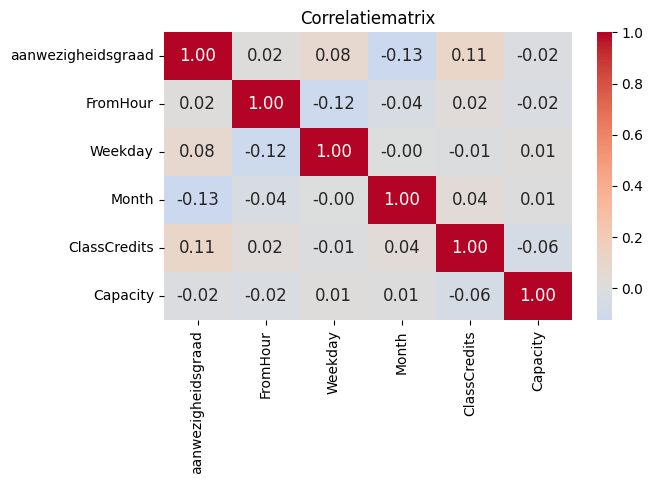

In [14]:
num_cols = ['aanwezigheidsgraad', 'FromHour', 'Weekday', 'Month', 'ClassCredits', 'Capacity']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlatiematrix')
plt.tight_layout()
plt.show()

## 4. Data cleaning

WiFi kan meer unieke apparaten detecteren dan het verwachte studentenaantal (docenten, bezoekers, meerdere apparaten per student). Waarden boven 1.5 worden beschouwd als foutief.

In [15]:
print(f'Rijen voor cleaning: {len(df):,}')

# Verwijder extreme uitschieters in de doelveranderlijke
df = df[df['aanwezigheidsgraad'] <= 1.5].copy()

# Verwijder lessen met te kleine groepen (weinig voorspellende waarde)
df = df[df['TotalStudents'] >= 5].copy()

# Verwijder rijen met ontbrekende waarden in essentiële kolommen
df.dropna(subset=['ClassCode', 'RoomCategory', 'ProgramName', 'CanonicalActivity'], inplace=True)

print(f'Rijen na cleaning:  {len(df):,}')
print(f'Aanwezigheidsgraad: min={df["aanwezigheidsgraad"].min():.2f}, max={df["aanwezigheidsgraad"].max():.2f}, gem={df["aanwezigheidsgraad"].mean():.2f}')

Rijen voor cleaning: 18,499
Rijen na cleaning:  6,188
Aanwezigheidsgraad: min=0.00, max=1.00, gem=0.33


## 5. Externe data

### 5.1 Feestdagen en vakanties

Nabijheid van een vakantieperiode kan de aanwezigheid beïnvloeden. We berekenen hoeveel dagen een les verwijderd is van de dichtstbijzijnde vakantiedag.

In [16]:
# Belgische feestdagen en HOGENT-vakanties voor academiejaar 2024-2025 (1e semester)
feestdagen = {
    date(2024, 11,  1),  # Allerheiligen
    date(2024, 11, 11),  # Wapenstilstand
    date(2024, 12, 25),  # Kerstmis
    date(2025,  1,  1),  # Nieuwjaar
}

vakantie_periodes = [
    (date(2024, 10, 28), date(2024, 11,  1)),   # herfstvakantie
    (date(2024, 12, 23), date(2025,  1,  5)),   # kerstvakantie
]

alle_vakantiedagen = set(feestdagen)
for start, einde in vakantie_periodes:
    dag = start
    while dag <= einde:
        alle_vakantiedagen.add(dag)
        dag += timedelta(days=1)

def dagen_tot_vakantie(d):
    d = d.date() if hasattr(d, 'date') else d
    for i in range(1, 15):
        if d + timedelta(days=i) in alle_vakantiedagen:
            return i
    return 14

def dagen_na_vakantie(d):
    d = d.date() if hasattr(d, 'date') else d
    for i in range(1, 15):
        if d - timedelta(days=i) in alle_vakantiedagen:
            return i
    return 14

df['dagen_tot_vakantie'] = df['FullDate'].apply(dagen_tot_vakantie)
df['dagen_na_vakantie']  = df['FullDate'].apply(dagen_na_vakantie)

print('Feestdagen/vakantiedagen verwerkt')
df[['dagen_tot_vakantie', 'dagen_na_vakantie']].describe().round(1)

Feestdagen/vakantiedagen verwerkt


,dagen_tot_vakantie,dagen_na_vakantie
count,6188.0,6188.0
mean,14.0,14.0
std,0.0,0.0
min,14.0,14.0
25%,14.0,14.0
50%,14.0,14.0
75%,14.0,14.0
max,14.0,14.0


### 5.2 Weerdata (Open-Meteo, Gent)

Dagelijkse weerdata voor Gent via de gratis Open-Meteo API (geen sleutel vereist).

In [17]:
start_date = df['FullDate'].min().strftime('%Y-%m-%d')
end_date   = df['FullDate'].max().strftime('%Y-%m-%d')

url = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude':   51.05,
    'longitude':   3.72,
    'start_date': start_date,
    'end_date':   end_date,
    'daily':      'temperature_2m_mean,precipitation_sum,weathercode',
    'timezone':   'Europe/Brussels',
}

response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()

weer_df = pd.DataFrame({
    'FullDate':  pd.to_datetime(data['daily']['time']),
    'gem_temp':  data['daily']['temperature_2m_mean'],
    'neerslag':  data['daily']['precipitation_sum'],
    'weercode':  data['daily']['weathercode'],
})
# WMO-code >= 51 = lichte regen of meer
weer_df['is_regen'] = (weer_df['weercode'] >= 51).astype(int)

print(f'Weerdata geladen: {len(weer_df)} dagen ({start_date} t/m {end_date})')
weer_df.head()

Weerdata geladen: 85 dagen (2025-09-25 t/m 2025-12-18)


,FullDate,gem_temp,neerslag,weercode,is_regen
0,2025-09-25,11.1,0.2,51,1
1,2025-09-26,11.3,0.1,51,1
2,2025-09-27,12.3,0.0,3,0
3,2025-09-28,13.2,0.0,3,0
4,2025-09-29,13.2,0.2,51,1


In [18]:
df = df.merge(weer_df[['FullDate', 'gem_temp', 'neerslag', 'is_regen']], on='FullDate', how='left')
print(f'Ontbrekende weerwaarden: {df[["gem_temp","neerslag","is_regen"]].isna().sum().to_dict()}')
df[['gem_temp', 'neerslag']].describe().round(2)

Ontbrekende weerwaarden: {'gem_temp': 0, 'neerslag': 0, 'is_regen': 0}


,gem_temp,neerslag
count,6188.00,6188.00
mean,10.23,1.72
std,3.60,3.13
min,-0.40,0.00
25%,7.60,0.00
50%,11.80,0.30
75%,13.10,2.10
max,14.40,17.50


## 6. Feature engineering

We maken nieuwe features die de aanwezigheid mogelijk beter verklaren.

In [19]:
# Lesduur in minuten
df['les_duur_min'] = (
    (df['UntilHour'] * 60 + df['UntilMinutes']) -
    (df['FromHour']  * 60 + df['FromMinutes'])
)

# Dagdeel op basis van startuur
def dagdeel(hour):
    if hour < 12:
        return 'ochtend'
    elif hour < 17:
        return 'namiddag'
    return 'avond'

df['dagdeel'] = df['FromHour'].apply(dagdeel)

# Weeknummer in het semester (semester start begin september)
semester_start = pd.Timestamp('2024-09-02')
df['week_in_semester'] = ((df['FullDate'] - semester_start).dt.days // 7 + 1).clip(1, 20)

# Verwachte bezettingsgraad van het lokaal
df['verwachte_bezetting'] = (
    df['TotalStudents'] / df['Capacity'].replace(0, np.nan)
).clip(0, 2)

print('Nieuwe features:')
df[['les_duur_min', 'dagdeel', 'week_in_semester', 'verwachte_bezetting']].describe().round(2)

Nieuwe features:


,les_duur_min,week_in_semester,verwachte_bezetting
count,6188.00,6188.0,6188.00
mean,131.57,20.0,0.48
std,43.36,0.0,0.38
min,60.00,20.0,0.02
25%,120.00,20.0,0.19
50%,120.00,20.0,0.37
75%,120.00,20.0,0.64
max,600.00,20.0,2.00


## 7. Voorbereiding voor de modellen

In [20]:
feature_cols_num = [
    'FromHour', 'Weekday', 'Month', 'week_in_semester',
    'ClassCredits', 'Capacity', 'les_duur_min',
    'gem_temp', 'neerslag', 'is_regen',
    'dagen_tot_vakantie', 'dagen_na_vakantie',
    'verwachte_bezetting', 'IsCourse', 'IsExam', 'IsPractical',
]

feature_cols_cat = [
    'ClassCode', 'RoomCategory', 'ProgramName', 'CanonicalActivity', 'dagdeel',
]

X = df[feature_cols_num + feature_cols_cat].copy()
y = df['aanwezigheidsgraad'].copy()

print(f'Features: {len(feature_cols_num)} numeriek + {len(feature_cols_cat)} categorisch = {X.shape[1]} totaal')
print(f'Doelveranderlijke: gemiddelde={y.mean():.3f}, std={y.std():.3f}')

Features: 16 numeriek + 5 categorisch = 21 totaal
Doelveranderlijke: gemiddelde=0.329, std=0.272


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Trainset: {len(X_train):,} rijen')
print(f'Testset:  {len(X_test):,} rijen')

Trainset: 4,950 rijen
Testset:  1,238 rijen


In [22]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False),
)

preprocessing = ColumnTransformer([
    ('num', num_pipeline, feature_cols_num),
    ('cat', cat_pipeline, feature_cols_cat),
])

## 8. Modellen trainen en vergelijken

We vergelijken vier modellen via 5-voudige kruisvalidatie op de trainset.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score

modellen = {
    'LinearRegression':       LinearRegression(),
    'DecisionTree':           DecisionTreeRegressor(max_depth=8, random_state=42),
    'RandomForest':           RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    'HistGradientBoosting':   HistGradientBoostingRegressor(max_iter=100, random_state=42),
}

resultaten = {}
for naam, model in modellen.items():
    pipe = Pipeline([('preprocessing', preprocessing), ('model', model)])
    scores = -cross_val_score(pipe, X_train, y_train,
                              scoring='neg_mean_absolute_error', cv=5)
    resultaten[naam] = scores
    print(f'{naam:<30}  MAE: {scores.mean():.4f}  ± {scores.std():.4f}')

LinearRegression                MAE: 0.1769  ± 0.0016
DecisionTree                    MAE: 0.1922  ± 0.0012
RandomForest                    MAE: 0.1360  ± 0.0033
HistGradientBoosting            MAE: 0.1503  ± 0.0009


In [24]:
res_df = pd.DataFrame({naam: scores for naam, scores in resultaten.items()}).T
res_df.columns = [f'fold_{i+1}' for i in range(5)]
res_df['gemiddelde_MAE'] = res_df.mean(axis=1)
res_df['std_MAE'] = res_df.std(axis=1)
res_df.sort_values('gemiddelde_MAE')[['gemiddelde_MAE', 'std_MAE']].round(4)

,gemiddelde_MAE,std_MAE
RandomForest,0.1360,0.0033
HistGradientBoosting,0.1503,0.0009
LinearRegression,0.1769,0.0016
DecisionTree,0.1922,0.0012


## 9. Beste model verfijnen (GridSearchCV)

We verfijnen het RandomForest-model via rasterzoeking over de belangrijkste hyperparameters.

In [25]:
from sklearn.model_selection import GridSearchCV

best_pipe = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(n_jobs=-1, random_state=42)),
])

param_grid = [
    {
        'model__n_estimators':    [100, 200],
        'model__max_depth':       [None, 10, 20],
        'model__min_samples_leaf': [1, 5],
    },
]

grid_search = GridSearchCV(
    best_pipe, param_grid,
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=1,
)
grid_search.fit(X_train, y_train)

print(f'Beste parameters: {grid_search.best_params_}')
print(f'Beste CV-MAE:     {-grid_search.best_score_:.4f}')

final_model = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Beste parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Beste CV-MAE:     0.1355


## 10. Evaluatie op de testset

In [26]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

y_pred = final_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'MAE  (Mean Absolute Error):  {mae:.4f}')
print(f'RMSE (Root Mean Sq. Error):  {rmse:.4f}')
print(f'R²:                          {r2:.4f}')
print()
print(f'Gemiddeld zit de voorspelling {mae*100:.1f} procentpunten van de werkelijkheid.')

MAE  (Mean Absolute Error):  0.1319
RMSE (Root Mean Sq. Error):  0.1810
R²:                          0.5721

Gemiddeld zit de voorspelling 13.2 procentpunten van de werkelijkheid.


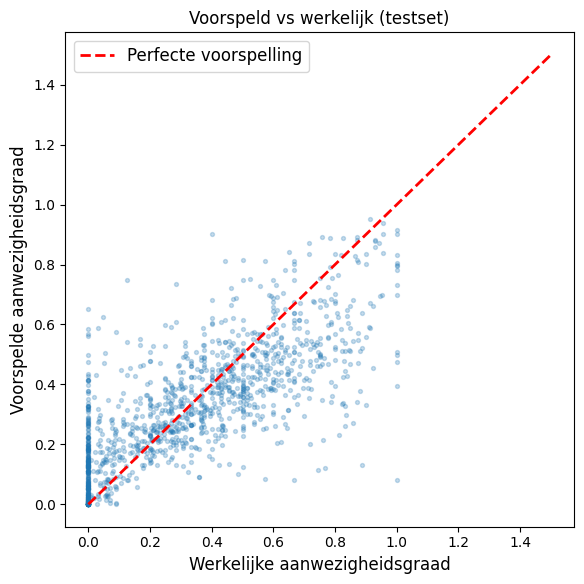

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.25, s=8)
ax.plot([0, 1.5], [0, 1.5], 'r--', linewidth=2, label='Perfecte voorspelling')
ax.set_xlabel('Werkelijke aanwezigheidsgraad')
ax.set_ylabel('Voorspelde aanwezigheidsgraad')
ax.set_title('Voorspeld vs werkelijk (testset)')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Belang van features

Welke factoren bepalen de aanwezigheid het meest?

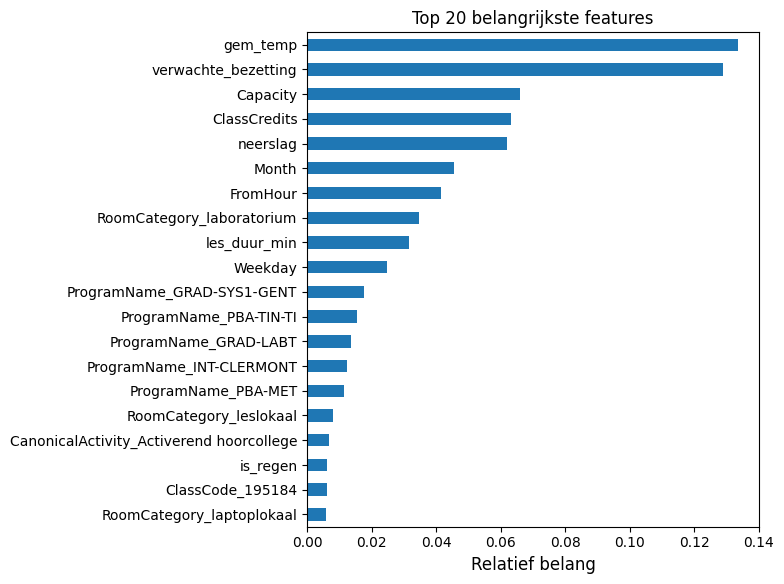


Top 10:
gem_temp                     0.1334
verwachte_bezetting          0.1288
Capacity                     0.0661
ClassCredits                 0.0633
neerslag                     0.0620
Month                        0.0456
FromHour                     0.0413
RoomCategory_laboratorium    0.0346
les_duur_min                 0.0315
Weekday                      0.0247


In [28]:
rf_model = final_model.named_steps['model']

cat_namen = (
    final_model.named_steps['preprocessing']
    .named_transformers_['cat']
    .named_steps['onehotencoder']
    .get_feature_names_out(feature_cols_cat)
    .tolist()
)
alle_namen = feature_cols_num + cat_namen

importances = pd.Series(rf_model.feature_importances_, index=alle_namen)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 20 belangrijkste features')
ax.set_xlabel('Relatief belang')
plt.tight_layout()
plt.show()

print('\nTop 10:')
print(top20.head(10).round(4).to_string())

## 12. Model en lookuptabellen opslaan

Naast het model slaan we ook lookuptabellen op zodat de Python-applicatie geen databaseverbinding nodig heeft.

In [29]:
# Lookuptabellen: RoomCode -> {Capacity, RoomCategory} en ClassCode -> {ClassCredits}
room_lookup  = df.groupby('RoomCode')[['Capacity', 'RoomCategory']].first().to_dict('index')
class_lookup = df.groupby('ClassCode')[['ClassCredits']].first().to_dict('index')

artifact = {
    'model':          final_model,
    'room_lookup':    room_lookup,
    'class_lookup':   class_lookup,
    'feature_cols_num': feature_cols_num,
    'feature_cols_cat': feature_cols_cat,
    'alle_vakantiedagen': alle_vakantiedagen,
    'semester_start': semester_start,
}

joblib.dump(artifact, 'model_aanwezigheden.pkl')
print('Opgeslagen: model_aanwezigheden.pkl')

Opgeslagen: model_aanwezigheden.pkl
